# VerrouDetector GOLD V2 — notebook complet séparé

Ce notebook entraîne le modèle binaire **VerrouDetector** séparément du modèle FastJudge.

Objectif :

```text
phrase + contexte + rôle
→ is_verrou_evidence true / false
```

Il utilise le dataset gold :

```text
C:\EnnoSmart\data\training\verrou_detection_dataset_gold.jsonl
```

Cette V2 ajoute :

```text
1. Split stratifié par projet
2. Augmentation sur TRAIN seulement
3. Multi-epochs pour obtenir de vraies courbes
4. Early stopping
5. Restauration automatique du meilleur epoch
6. Sauvegarde du meilleur modèle
```

In [1]:
from pathlib import Path
import json
import copy
import joblib
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight

print("Imports OK")

Imports OK


In [2]:
ROOT = Path(r"C:\EnnoSmart")

DATASET_PATH = ROOT / "data" / "training" / "verrou_detection_dataset_gold.jsonl"

MODEL_DIR = ROOT / "models" / "fastjudge"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "verrou_detector_gold_v2.pkl"
REPORT_PATH = MODEL_DIR / "verrou_detector_gold_v2_report.json"
PREDICTIONS_PATH = MODEL_DIR / "verrou_detector_gold_v2_predictions.csv"
ERRORS_PATH = MODEL_DIR / "verrou_detector_gold_v2_errors.csv"
CURVES_PATH = MODEL_DIR / "verrou_detector_gold_v2_training_curves.csv"

RANDOM_STATE = 42
N_EPOCHS = 12
PATIENCE = 3
ALPHA = 5e-4
AUGMENT_TRAIN = True

print("Dataset :", DATASET_PATH)
print("MODEL_PATH:", MODEL_PATH)
print("N_EPOCHS:", N_EPOCHS)
print("PATIENCE:", PATIENCE)
print("ALPHA:", ALPHA)

Dataset : C:\EnnoSmart\data\training\verrou_detection_dataset_gold.jsonl
MODEL_PATH: C:\EnnoSmart\models\fastjudge\verrou_detector_gold_v2.pkl
N_EPOCHS: 12
PATIENCE: 3
ALPHA: 0.0005


In [3]:
def read_jsonl(path: Path):
    rows = []
    if not path.exists():
        raise FileNotFoundError(f"Dataset introuvable : {path}")
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def normalize_text(x):
    s = str(x or "")
    s = s.replace("\u00a0", " ").replace("\ufeff", " ")
    s = " ".join(s.split())
    return s.strip()


def to_bool(x):
    if isinstance(x, bool):
        return x
    s = str(x or "").strip().lower()
    return s in {"true", "1", "yes", "oui", "vrai"}


def build_input_text(row):
    # Attention : pas de verrou_type_auto, verrou_rule, is_verrou_evidence_auto.
    # Sinon fuite de label.
    text = normalize_text(row.get("text"))
    before = normalize_text(row.get("context_before"))
    after = normalize_text(row.get("context_after"))
    role = normalize_text(row.get("role_gold") or row.get("role_final"))
    candidate = normalize_text(row.get("candidate_role") or row.get("role_initial"))
    source = normalize_text(row.get("source_type"))
    project_type = normalize_text(row.get("project_type"))

    return (
        f"{text}\n"
        f"{text}\n"
        f"CONTEXT_BEFORE: {before}\n"
        f"CONTEXT_AFTER: {after}\n"
        f"ROLE: {role}\n"
        f"CANDIDATE_ROLE: {candidate}\n"
        f"SOURCE_TYPE: {source}\n"
        f"PROJECT_TYPE: {project_type}"
    )


def build_input_text_variant(row, mode="full"):
    text = normalize_text(row.get("text"))
    before = normalize_text(row.get("context_before"))
    after = normalize_text(row.get("context_after"))
    role = normalize_text(row.get("role_gold") or row.get("role_final"))
    candidate = normalize_text(row.get("candidate_role") or row.get("role_initial"))
    source = normalize_text(row.get("source_type"))
    project_type = normalize_text(row.get("project_type"))

    if mode == "text_only":
        return f"{text}\n{text}"

    if mode == "no_role":
        return (
            f"{text}\n"
            f"{text}\n"
            f"CONTEXT_BEFORE: {before}\n"
            f"CONTEXT_AFTER: {after}\n"
            f"SOURCE_TYPE: {source}\n"
            f"PROJECT_TYPE: {project_type}"
        )

    if mode == "short_context":
        return (
            f"{text}\n"
            f"CONTEXT_BEFORE: {before[:300]}\n"
            f"CONTEXT_AFTER: {after[:300]}\n"
            f"ROLE: {role}\n"
            f"CANDIDATE_ROLE: {candidate}"
        )

    return build_input_text(row)


def prepare_dataset(rows, keep_bad_quality=False):
    X, y, kept = [], [], []
    for row in rows:
        text = normalize_text(row.get("text"))
        if len(text) < 30:
            continue

        quality = normalize_text(row.get("quality_gold")).lower()
        if quality == "bad" and not keep_bad_quality:
            continue

        label = 1 if to_bool(row.get("is_verrou_evidence")) else 0
        X.append(build_input_text(row))
        y.append(label)
        kept.append(row)
    return X, y, kept


def print_distribution(title, y):
    c = Counter(y)
    print("\n" + title)
    print("total      :", len(y))
    print("verrou     :", c.get(1, 0))
    print("non-verrou :", c.get(0, 0))
    if len(y) > 0:
        print("ratio verrou:", round(c.get(1, 0) / len(y), 3))


def best_threshold_metrics(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    best = {"threshold": 0.50, "f1": 0.0, "precision": 0.0, "recall": 0.0}
    for t in thresholds:
        pred = (proba >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        p = precision_score(y_true, pred, zero_division=0)
        r = recall_score(y_true, pred, zero_division=0)
        if f1 > best["f1"]:
            best = {"threshold": float(t), "f1": float(f1), "precision": float(p), "recall": float(r)}
    return best

In [4]:
rows = read_jsonl(DATASET_PATH)
X, y, kept_rows = prepare_dataset(rows)

print("Lignes dataset :", len(rows))
print("Lignes utilisées :", len(X))
print_distribution("Distribution totale", y)

df = pd.DataFrame(kept_rows)
display(df[[
    "project_id", "source_type", "role_gold", "candidate_role",
    "is_verrou_evidence", "verrou_type", "quality_gold", "text"
]].head(15))

Lignes dataset : 1200
Lignes utilisées : 1200

Distribution totale
total      : 1200
verrou     : 612
non-verrou : 588
ratio verrou: 0.51


,project_id,source_type,role_gold,candidate_role,is_verrou_evidence,verrou_type,quality_gold,text
0,projet_4_,raw,verrou,limite,True,absence_referentiel,good,"De ce fait, au démarrage des travaux, aucun pr..."
1,projet_23_,raw,methode,methode,True,absence_referentiel,medium,Il n’existe pas à ce jour de protocole validé ...
2,projet_4_,raw,methode,methode,True,absence_referentiel,medium,"En effet, bien que nous puissions nous appuyer..."
3,projet_10_,raw,verrou,limite,True,autre_verrou,good,Il s’agit aussi d’un défis technique difficile...
4,projet_10_,raw,verrou,verrou,True,limite_etat_art,good,"De surcroit, la plupart des recherches et des ..."
5,projet_10_,raw,verrou,verrou,True,autre_verrou,good,"Cependant, cette approche a mis en lumière des..."
6,projet_10_,raw,verrou,verrou,True,incertitude_resultat,good,"En outre, la plupart des recherches et des ana..."
7,projet_10_,raw,verrou,verrou,False,,good,Apprentissage par transfert L’apprentissage pa...
8,projet_11_,cir_final,verrou,verrou,True,difficulte_mesure,medium,Ces objectifs s’inscrivent dans une démarche e...
9,projet_11_,cir_final,verrou,verrou,True,temps_reel_latency,good,Manque de robustesse des approches profondes (...


In [5]:
print("Qualité gold :")
display(df["quality_gold"].fillna("").value_counts())

print("Distribution par label :")
display(df["is_verrou_evidence"].value_counts())

print("Distribution par rôle :")
display(df["role_gold"].fillna("").value_counts())

print("Types de verrou uniquement pour les positifs :")
display(df[df["is_verrou_evidence"] == True]["verrou_type"].fillna("").value_counts())

print("Nombre de projets :", df["project_id"].nunique())

Qualité gold :


quality_gold
good      1030
medium     170
Name: count, dtype: int64

Distribution par label :


is_verrou_evidence
True     612
False    588
Name: count, dtype: int64

Distribution par rôle :


role_gold
resultat        356
verrou          259
limite          234
methode         180
contribution    129
parametre        28
objectif         10
variable          3
hypothese         1
Name: count, dtype: int64

Types de verrou uniquement pour les positifs :


verrou_type
incertitude_resultat        182
autre_verrou                 93
temps_reel_latency           78
difficulte_modelisation      43
variabilite_conditions       43
difficulte_mesure            41
verrou_explicit              38
non_reproductibilite         25
performance_insuffisante     19
absence_referentiel          11
limite_etat_art              11
complexite_systeme           11
passage_echelle              11
manque_donnees                6
Name: count, dtype: int64

Nombre de projets : 15


In [6]:
groups = np.array([r.get("project_id", "unknown") for r in kept_rows])
y_array = np.array(y)
indices = np.arange(len(X))

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

best_split = None
best_score = 999.0
global_ratio = y_array.mean()

print("Ratio global verrou:", round(float(global_ratio), 3))

for fold_id, (train_idx, val_idx) in enumerate(splitter.split(indices, y_array, groups), start=1):
    y_train_tmp = y_array[train_idx]
    y_val_tmp = y_array[val_idx]

    train_ratio = y_train_tmp.mean()
    val_ratio = y_val_tmp.mean()

    score = abs(val_ratio - global_ratio)

    print(
        f"Fold {fold_id} | train={len(train_idx)} val={len(val_idx)} | "
        f"train_pos={train_ratio:.3f} val_pos={val_ratio:.3f} | score={score:.4f}"
    )

    if score < best_score:
        best_score = score
        best_split = (train_idx, val_idx, fold_id)

train_idx, val_idx, selected_fold = best_split

X_train = [X[i] for i in train_idx]
X_val = [X[i] for i in val_idx]
y_train = [y[i] for i in train_idx]
y_val = [y[i] for i in val_idx]
rows_train = [kept_rows[i] for i in train_idx]
rows_val = [kept_rows[i] for i in val_idx]

split_name = f"StratifiedGroupKFold_fold_{selected_fold}"

print("\nSplit utilisé :", split_name)
print("Train :", len(X_train))
print("Val   :", len(X_val))
print_distribution("Distribution train", y_train)
print_distribution("Distribution val", y_val)
print("Projets train :", len(set(r.get("project_id") for r in rows_train)))
print("Projets val   :", len(set(r.get("project_id") for r in rows_val)))

Ratio global verrou: 0.51
Fold 1 | train=928 val=272 | train_pos=0.460 val_pos=0.680 | score=0.1701
Fold 2 | train=961 val=239 | train_pos=0.532 val_pos=0.423 | score=0.0874
Fold 3 | train=971 val=229 | train_pos=0.520 val_pos=0.467 | score=0.0428
Fold 4 | train=980 val=220 | train_pos=0.539 val_pos=0.382 | score=0.1282
Fold 5 | train=960 val=240 | train_pos=0.497 val_pos=0.562 | score=0.0525

Split utilisé : StratifiedGroupKFold_fold_3
Train : 971
Val   : 229

Distribution train
total      : 971
verrou     : 505
non-verrou : 466
ratio verrou: 0.52

Distribution val
total      : 229
verrou     : 107
non-verrou : 122
ratio verrou: 0.467
Projets train : 11
Projets val   : 4


In [7]:
def augment_train(X_train, y_train, rows_train):
    aug_X = list(X_train)
    aug_y = list(y_train)
    aug_rows = list(rows_train)

    for x, label, row in zip(X_train, y_train, rows_train):
        hard_negative = str(row.get("hard_negative", "")).lower() == "true"

        if label == 1:
            aug_X.append(build_input_text_variant(row, mode="text_only"))
            aug_y.append(label)
            aug_rows.append(row)

            aug_X.append(build_input_text_variant(row, mode="no_role"))
            aug_y.append(label)
            aug_rows.append(row)

        if label == 0 and hard_negative:
            aug_X.append(build_input_text_variant(row, mode="no_role"))
            aug_y.append(label)
            aug_rows.append(row)

        aug_X.append(build_input_text_variant(row, mode="short_context"))
        aug_y.append(label)
        aug_rows.append(row)

    return aug_X, aug_y, aug_rows


if AUGMENT_TRAIN:
    X_train, y_train, rows_train = augment_train(X_train, y_train, rows_train)

print("Après augmentation TRAIN")
print("Train :", len(X_train))
print("Val   :", len(X_val))
print_distribution("Distribution train augmentée", y_train)
print_distribution("Distribution val non augmentée", y_val)

Après augmentation TRAIN
Train : 3167
Val   : 229

Distribution train augmentée
total      : 3167
verrou     : 2020
non-verrou : 1147
ratio verrou: 0.638

Distribution val non augmentée
total      : 229
verrou     : 107
non-verrou : 122
ratio verrou: 0.467


In [8]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode",
    lowercase=True,
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 6),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    strip_accents="unicode",
    lowercase=True,
)

features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf),
])

print("Fit vectorizer...")
X_train_vec = features.fit_transform(X_train)
X_val_vec = features.transform(X_val)

print("X_train_vec:", X_train_vec.shape)
print("X_val_vec  :", X_val_vec.shape)

Fit vectorizer...
X_train_vec: (3167, 181741)
X_val_vec  : (229, 181741)


In [9]:
classes = np.array([0, 1])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.array(y_train)
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("Poids classes :")
print("0 = non-verrou :", class_weights[0])
print("1 = verrou     :", class_weights[1])

clf = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=ALPHA,
    max_iter=1,
    tol=None,
    learning_rate="optimal",
    class_weight=class_weights,
    average=True,
    random_state=RANDOM_STATE,
)

print("Modèle :", clf)

Poids classes :
0 = non-verrou : 1.3805579773321708
1 = verrou     : 0.7839108910891089
Modèle : SGDClassifier(alpha=0.0005, average=True,
              class_weight={0: 1.3805579773321708, 1: 0.7839108910891089},
              loss='log_loss', max_iter=1, random_state=42, tol=None)


In [10]:
history = []

X_train_arr = X_train_vec
y_train_arr = np.array(y_train)

best_score = -1.0
best_epoch = None
best_clf = None
best_threshold_at_epoch = 0.50
epochs_without_improvement = 0

for epoch in range(1, N_EPOCHS + 1):
    X_epoch, y_epoch = shuffle(X_train_arr, y_train_arr, random_state=RANDOM_STATE + epoch)

    if epoch == 1:
        clf.partial_fit(X_epoch, y_epoch, classes=classes)
    else:
        clf.partial_fit(X_epoch, y_epoch)

    train_pred = clf.predict(X_train_vec)
    val_pred = clf.predict(X_val_vec)

    val_proba = clf.predict_proba(X_val_vec)[:, 1]

    val_f1_050 = f1_score(y_val, val_pred, zero_division=0)
    val_precision_050 = precision_score(y_val, val_pred, zero_division=0)
    val_recall_050 = recall_score(y_val, val_pred, zero_division=0)

    best_t = best_threshold_metrics(y_val, val_proba)

    row = {
        "epoch": epoch,

        "train_accuracy": accuracy_score(y_train, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),

        "train_precision": precision_score(y_train, train_pred, zero_division=0),
        "val_precision_050": val_precision_050,

        "train_recall": recall_score(y_train, train_pred, zero_division=0),
        "val_recall_050": val_recall_050,

        "train_f1": f1_score(y_train, train_pred, zero_division=0),
        "val_f1_050": val_f1_050,

        "val_best_threshold": best_t["threshold"],
        "val_best_precision": best_t["precision"],
        "val_best_recall": best_t["recall"],
        "val_best_f1": best_t["f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"val_f1_050={row['val_f1_050']:.4f} | "
        f"best_f1={row['val_best_f1']:.4f} | "
        f"best_thr={row['val_best_threshold']:.3f} | "
        f"best_p={row['val_best_precision']:.3f} | "
        f"best_r={row['val_best_recall']:.3f}"
    )

    current_score = row["val_best_f1"]

    if current_score > best_score:
        best_score = current_score
        best_epoch = epoch
        best_clf = copy.deepcopy(clf)
        best_threshold_at_epoch = float(best_t["threshold"])
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping à l'epoch {epoch}. Meilleur epoch : {best_epoch}")
        break

clf = best_clf

history_df = pd.DataFrame(history)
history_df.to_csv(CURVES_PATH, index=False, encoding="utf-8-sig")

display(history_df)

print("Meilleur epoch :", best_epoch)
print("Meilleur val_best_f1 :", best_score)
print("Meilleur threshold :", best_threshold_at_epoch)
print("Courbes CSV sauvegardées :", CURVES_PATH)

Epoch 01/12 | val_f1_050=0.7487 | best_f1=0.8213 | best_thr=0.455 | best_p=0.850 | best_r=0.794
Epoch 02/12 | val_f1_050=0.7604 | best_f1=0.8261 | best_thr=0.397 | best_p=0.772 | best_r=0.888
Epoch 03/12 | val_f1_050=0.7461 | best_f1=0.8261 | best_thr=0.401 | best_p=0.772 | best_r=0.888
Epoch 04/12 | val_f1_050=0.7565 | best_f1=0.8319 | best_thr=0.412 | best_p=0.790 | best_r=0.879
Epoch 05/12 | val_f1_050=0.7629 | best_f1=0.8319 | best_thr=0.415 | best_p=0.790 | best_r=0.879
Epoch 06/12 | val_f1_050=0.7629 | best_f1=0.8356 | best_thr=0.416 | best_p=0.797 | best_r=0.879
Epoch 07/12 | val_f1_050=0.7629 | best_f1=0.8356 | best_thr=0.418 | best_p=0.797 | best_r=0.879
Epoch 08/12 | val_f1_050=0.7629 | best_f1=0.8364 | best_thr=0.430 | best_p=0.814 | best_r=0.860
Epoch 09/12 | val_f1_050=0.7629 | best_f1=0.8364 | best_thr=0.431 | best_p=0.814 | best_r=0.860
Epoch 10/12 | val_f1_050=0.7629 | best_f1=0.8364 | best_thr=0.432 | best_p=0.814 | best_r=0.860
Epoch 11/12 | val_f1_050=0.7629 | best_f

,epoch,train_accuracy,val_accuracy,train_precision,val_precision_050,train_recall,val_recall_050,train_f1,val_f1_050,val_best_threshold,val_best_precision,val_best_recall,val_best_f1
0,1,0.983265,0.794760,0.997975,0.875000,0.975743,0.654206,0.986733,0.748663,0.454859,0.850000,0.794393,0.821256
1,2,0.988949,0.799127,0.998994,0.858824,0.983663,0.682243,0.991270,0.760417,0.396903,0.772358,0.887850,0.826087
2,3,0.990212,0.786026,0.998996,0.837209,0.985644,0.672897,0.992275,0.746114,0.400536,0.772358,0.887850,0.826087
3,4,0.991159,0.794760,0.998998,0.848837,0.987129,0.682243,0.993028,0.756477,0.412248,0.789916,0.878505,0.831858
4,5,0.991790,0.799127,0.998999,0.850575,0.988119,0.691589,0.993529,0.762887,0.415032,0.789916,0.878505,0.831858
5,6,0.992738,0.799127,0.999000,0.850575,0.989604,0.691589,0.994280,0.762887,0.416426,0.796610,0.878505,0.835556
6,7,0.992738,0.799127,0.999000,0.850575,0.989604,0.691589,0.994280,0.762887,0.417600,0.796610,0.878505,0.835556
7,8,0.992738,0.799127,0.999000,0.850575,0.989604,0.691589,0.994280,0.762887,0.429953,0.814159,0.859813,0.836364
8,9,0.992738,0.799127,0.999000,0.850575,0.989604,0.691589,0.994280,0.762887,0.431147,0.814159,0.859813,0.836364
9,10,0.992738,0.799127,0.999000,0.850575,0.989604,0.691589,0.994280,0.762887,0.431519,0.814159,0.859813,0.836364


Meilleur epoch : 8
Meilleur val_best_f1 : 0.8363636363636363
Meilleur threshold : 0.42995291172300976
Courbes CSV sauvegardées : C:\EnnoSmart\models\fastjudge\verrou_detector_gold_v2_training_curves.csv


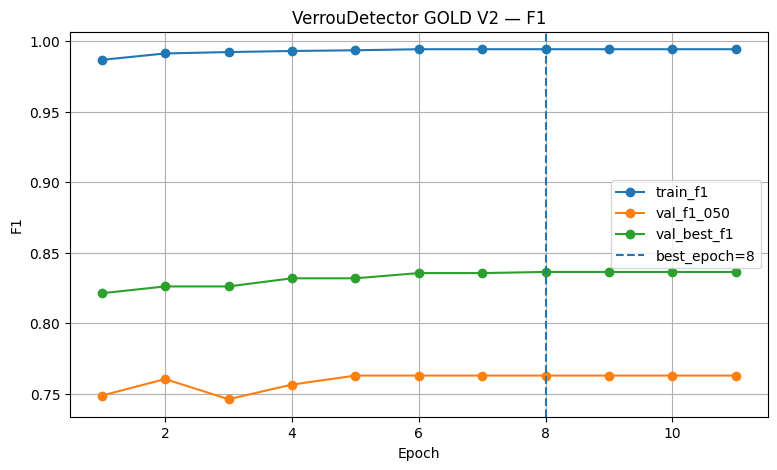

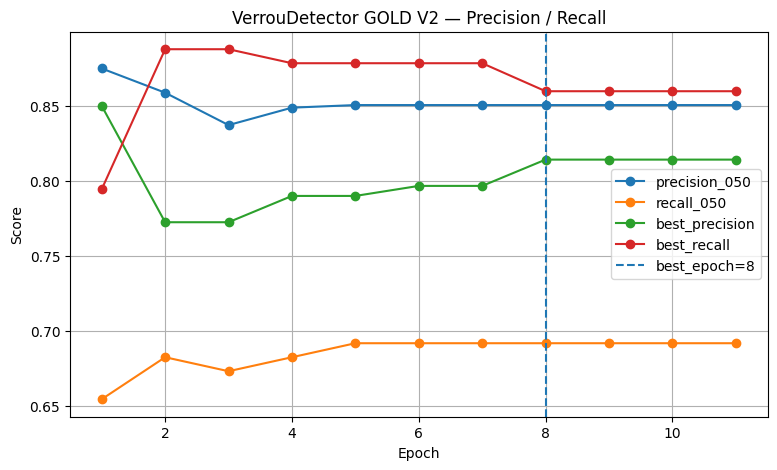

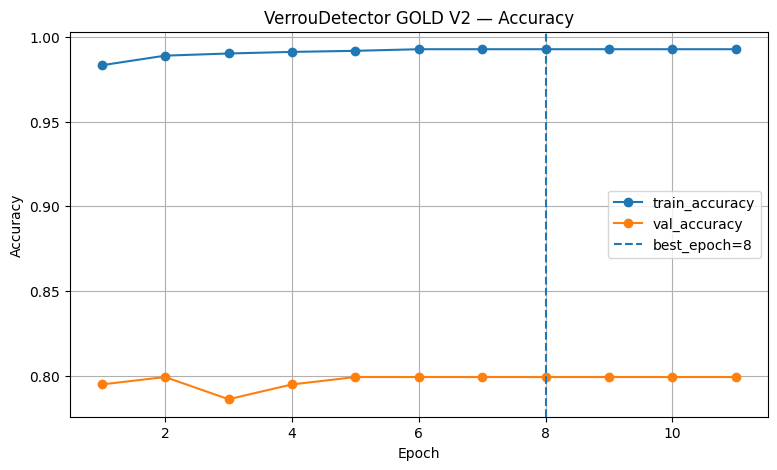

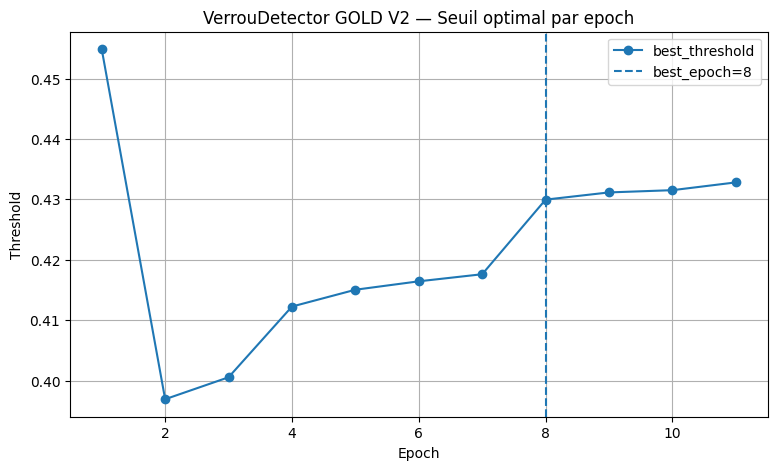

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_f1"], marker="o", label="train_f1")
plt.plot(history_df["epoch"], history_df["val_f1_050"], marker="o", label="val_f1_050")
plt.plot(history_df["epoch"], history_df["val_best_f1"], marker="o", label="val_best_f1")
plt.axvline(best_epoch, linestyle="--", label=f"best_epoch={best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("VerrouDetector GOLD V2 — F1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["val_precision_050"], marker="o", label="precision_050")
plt.plot(history_df["epoch"], history_df["val_recall_050"], marker="o", label="recall_050")
plt.plot(history_df["epoch"], history_df["val_best_precision"], marker="o", label="best_precision")
plt.plot(history_df["epoch"], history_df["val_best_recall"], marker="o", label="best_recall")
plt.axvline(best_epoch, linestyle="--", label=f"best_epoch={best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("VerrouDetector GOLD V2 — Precision / Recall")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="train_accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="val_accuracy")
plt.axvline(best_epoch, linestyle="--", label=f"best_epoch={best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VerrouDetector GOLD V2 — Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["val_best_threshold"], marker="o", label="best_threshold")
plt.axvline(best_epoch, linestyle="--", label=f"best_epoch={best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Threshold")
plt.title("VerrouDetector GOLD V2 — Seuil optimal par epoch")
plt.legend()
plt.grid(True)
plt.show()

Seuil = 0.50
Accuracy : 0.7991266375545851
Precision: 0.8505747126436781
Recall   : 0.6915887850467289
F1       : 0.7628865979381443
                 precision    recall  f1-score   support

     not_verrou       0.77      0.89      0.83       122
verrou_evidence       0.85      0.69      0.76       107

       accuracy                           0.80       229
      macro avg       0.81      0.79      0.79       229
   weighted avg       0.81      0.80      0.80       229



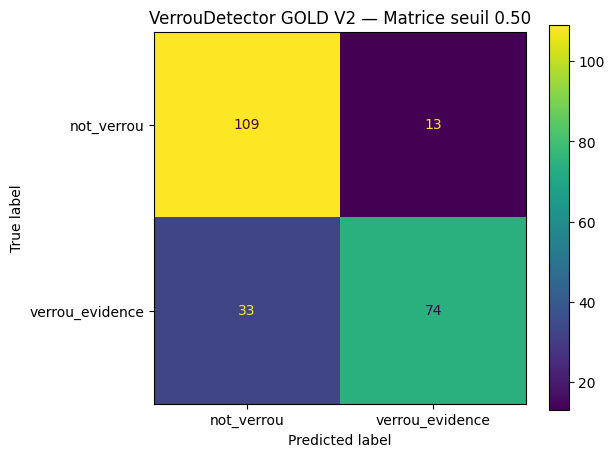

In [12]:
val_proba = clf.predict_proba(X_val_vec)[:, 1]

y_val_pred_050 = (val_proba >= 0.50).astype(int)

print("Seuil = 0.50")
print("Accuracy :", accuracy_score(y_val, y_val_pred_050))
print("Precision:", precision_score(y_val, y_val_pred_050, zero_division=0))
print("Recall   :", recall_score(y_val, y_val_pred_050, zero_division=0))
print("F1       :", f1_score(y_val, y_val_pred_050, zero_division=0))

report_text_050 = classification_report(
    y_val,
    y_val_pred_050,
    target_names=["not_verrou", "verrou_evidence"],
    zero_division=0
)

report_dict_050 = classification_report(
    y_val,
    y_val_pred_050,
    target_names=["not_verrou", "verrou_evidence"],
    output_dict=True,
    zero_division=0
)

print(report_text_050)

cm = confusion_matrix(y_val, y_val_pred_050, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["not_verrou", "verrou_evidence"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("VerrouDetector GOLD V2 — Matrice seuil 0.50")
plt.show()

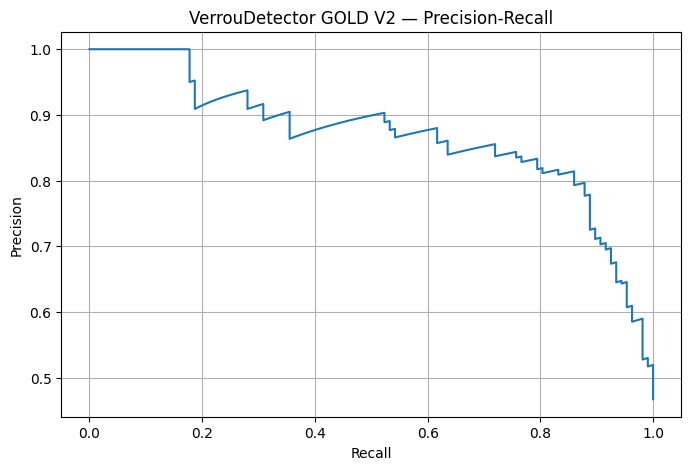

Meilleur seuil selon F1 :
{'threshold': 0.42995291172300976, 'f1': 0.8363636363636363, 'precision': 0.8141592920353983, 'recall': 0.8598130841121495}


,threshold,precision,recall,f1,accuracy,predicted_positive
0,0.300000,0.618182,0.953271,0.750000,0.703057,165
1,0.340000,0.675676,0.934579,0.784314,0.759825,148
2,0.350000,0.678082,0.925234,0.782609,0.759825,146
3,0.400000,0.760000,0.887850,0.818966,0.816594,125
4,0.450000,0.817308,0.794393,0.805687,0.820961,104
5,0.500000,0.850575,0.691589,0.762887,0.799127,87
6,0.550000,0.869565,0.560748,0.681818,0.755459,69
7,0.600000,0.898305,0.495327,0.638554,0.737991,59
8,0.650000,0.882353,0.420561,0.569620,0.703057,51
9,0.700000,0.872340,0.383178,0.532468,0.685590,47


threshold_default: 0.42995291172300976
threshold_safe: 0.5


In [13]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, val_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("VerrouDetector GOLD V2 — Precision-Recall")
plt.grid(True)
plt.show()

best_f1 = best_threshold_metrics(y_val, val_proba)

print("Meilleur seuil selon F1 :")
print(best_f1)

threshold_rows = []

for t in [0.30, 0.34, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, best_f1["threshold"]]:
    pred = (val_proba >= t).astype(int)
    row = {
        "threshold": float(t),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "accuracy": accuracy_score(y_val, pred),
        "predicted_positive": int(pred.sum()),
    }
    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

threshold_default = float(best_f1["threshold"])
threshold_safe = 0.50

print("threshold_default:", threshold_default)
print("threshold_safe:", threshold_safe)

In [14]:
y_val_pred_best = (val_proba >= threshold_default).astype(int)

errors = []

for row, true, pred, score in zip(rows_val, y_val, y_val_pred_best, val_proba):
    if int(true) != int(pred):
        errors.append({
            "project_id": row.get("project_id"),
            "source_type": row.get("source_type"),
            "source_doc": row.get("source_doc"),
            "role_gold": row.get("role_gold"),
            "candidate_role": row.get("candidate_role"),
            "true_is_verrou": bool(true),
            "pred_is_verrou": bool(pred),
            "verrou_score": round(float(score), 4),
            "verrou_type_gold": row.get("verrou_type", ""),
            "quality_gold": row.get("quality_gold", ""),
            "text": row.get("text"),
            "context_before": row.get("context_before"),
            "context_after": row.get("context_after"),
        })

errors_df = pd.DataFrame(errors)
errors_df.to_csv(ERRORS_PATH, index=False, encoding="utf-8-sig")

print("Nombre erreurs :", len(errors_df))
print("Erreurs sauvegardées :", ERRORS_PATH)

if len(errors_df) > 0:
    display(errors_df.sort_values("verrou_score", ascending=False).head(80))
else:
    print("Aucune erreur au meilleur seuil.")

Nombre erreurs : 36
Erreurs sauvegardées : C:\EnnoSmart\models\fastjudge\verrou_detector_gold_v2_errors.csv


,project_id,source_type,source_doc,role_gold,candidate_role,true_is_verrou,pred_is_verrou,verrou_score,verrou_type_gold,quality_gold,text,context_before,context_after
16,projet_23_,raw,HCM_dossier 2024_2025-05-22_AG.docx,verrou,verrou,False,True,0.8193,,good,Ce projet a permis d’identifier des verrous sp...,,La transformation du mode de fabrication a éga...
0,projet_10_,raw,DOSSIER JEI.pdf,verrou,verrou,False,True,0.8122,,good,Apprentissage par transfert L’apprentissage pa...,,Il vise à améliorer les performances de l’appr...
13,projet_10_,raw,ABINNOV_DT-2023_ BATREND_VF_AD.docx,verrou,verrou,False,True,0.7776,,good,Cette contribution de cette année a permis de ...,Ce modèle a donné des résultats très performan...,Nous envisageons également de traiter la probl...
24,projet_10_,raw,ABINNOV_DT-2023_ BATREND_V1.1_AD.docx,methode,verrou,False,True,0.7602,,good,Dans le cadre de notre projet visant à lever l...,,La première phase de notre démarche a consisté...
14,projet_10_,raw,ABINNOV_DT-2023_ BATREND_V1.2_AD.docx,verrou,verrou,False,True,0.7222,,good,Cette contribution de cette année a permis de ...,Ce modèle a donné des résultats très performan...,
15,projet_17_,cir_final,FEV_STS_CIR2020_07_A3m2_DCP_Annoté.docx,verrou,verrou,False,True,0.7216,,good,Des itérations successives ont permis d’affine...,Retour d’expérience et itérations Les résultat...,Le travail sur le multi-instance du SignalGene...
7,projet_10_,raw,Nouveau Modele NLP.pdf,resultat,resultat,False,True,0.5862,,good,Ces modèles donnent des résultats insatisfaisa...,Etat de l’art Actuellement il existe essentiel...,Nous avons essayé de réaliser un réglage fin (...
21,projet_10_,raw,ABINNOV_DT-2023_ BATREND_V1.1_AD.docx,resultat,resultat,False,True,0.5809,,good,"Cependant, ses résultats n’étaient pas satisfa...","Parmi eux, le modèle mDeBERTa s'est distingué ...","Ensuite, nous avons mis en œuvre une première ..."
12,projet_17_,cir_final,FEV_STS_CIR2020_09_A1a2_MultiMaster_Annoté.docx,hypothese,hypothese,False,True,0.5649,,good,"Avec cette option, il est possible de raccorde...","Par ailleurs, le protocole étendu EtherCAT P p...",La gamme complète du câblage Ethernet peut don...
26,projet_10_,raw,DOSSIER JEI.pdf,methode,methode,False,True,0.5223,,good,"Elle permet de surveiller, de mesurer et d’ana...","Proceedings of the IEEE, 109(1) :43–76, 2020 4...",Il s’agit donc d’une solution intelligente bas...


In [15]:
pred_rows = []

for row, true, score in zip(rows_val, y_val, val_proba):
    pred_default = int(score >= threshold_default)
    pred_safe = int(score >= threshold_safe)

    pred_rows.append({
        "project_id": row.get("project_id"),
        "source_type": row.get("source_type"),
        "source_doc": row.get("source_doc"),
        "role_gold": row.get("role_gold"),
        "candidate_role": row.get("candidate_role"),
        "verrou_type_gold": row.get("verrou_type", ""),
        "quality_gold": row.get("quality_gold", ""),

        "is_verrou_true": bool(true),
        "is_verrou_pred_default": bool(pred_default),
        "is_verrou_pred_safe": bool(pred_safe),
        "verrou_score": round(float(score), 4),
        "is_correct_default": bool(int(true) == pred_default),

        "text": row.get("text"),
        "context_before": row.get("context_before"),
        "context_after": row.get("context_after"),
    })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8-sig")

print("Prédictions sauvegardées :", PREDICTIONS_PATH)
display(pred_df.sort_values("verrou_score", ascending=False).head(30))

Prédictions sauvegardées : C:\EnnoSmart\models\fastjudge\verrou_detector_gold_v2_predictions.csv


,project_id,source_type,source_doc,role_gold,candidate_role,verrou_type_gold,quality_gold,is_verrou_true,is_verrou_pred_default,is_verrou_pred_safe,verrou_score,is_correct_default,text,context_before,context_after
44,projet_23_,raw,HCM_dossier 2024_2025-05-22_AG.docx,verrou,verrou,non_reproductibilite,good,True,True,True,0.9223,True,Le développement du nouveau système de fabrica...,,Deux grandes problématiques se sont particuliè...
3,projet_10_,raw,ABINNOV_DT-2023_ BATREND_V1.1_AD.docx,verrou,verrou,autre_verrou,good,True,True,True,0.9005,True,"Cependant, cette approche a mis en lumière des...","Ensuite, nous avons mis en œuvre une première ...","En outre, nous avons mis en œuvre une deuxième..."
61,projet_17_,cir_final,FEV_STS_CIR2020_07_A3m2_DCP_Annoté.docx,verrou,verrou,temps_reel_latency,good,True,True,True,0.8786,True,"La gestion de ces accès concurrents, tout en m...","En effet, lorsqu’une variable est mise à jour ...",Il sera essentiel de développer un mécanisme r...
72,projet_10_,raw,ABINNOV_DT-2023_ BATREND_V1.2_AD.docx,verrou,verrou,temps_reel_latency,good,True,True,True,0.8776,True,"Dans le contexte d’écoute sociale, la surveill...",,"Ce défi est multifactoriel, nécessitant la ges..."
76,projet_10_,raw,ABINNOV_DT-2023_ BATREND_V1.1_AD.docx,verrou,verrou,temps_reel_latency,good,True,True,True,0.8761,True,"Dans le contexte de l’écoute sociale, la surve...",,"Ce défi est multifactoriel, nécessitant la ges..."
45,projet_23_,raw,HCM_dossier 2024_2025-05-22_AG.docx,verrou,verrou,non_reproductibilite,good,True,True,True,0.8711,True,Lors de l’élaboration de notre nouveau procédé...,,"Malheureusement, les premiers essais industrie..."
66,projet_17_,cir_final,FEV_STS_CIR2020_08_A1a2_CDU_amélioré_SE.docx,verrou,verrou,temps_reel_latency,good,True,True,True,0.8695,True,"Toutefois, cette approche soulève des difficul...","Pour cela, nous avons travaillé sur l’intégrat...",| --------------------------------------------...
82,projet_17_,cir_final,FEV_STS_CIR2020_07_A3m2_DCP_Annoté.docx,verrou,verrou,autre_verrou,good,True,True,True,0.8671,True,"Garantir des performances optimales, même sur ...",Impact des nouvelles fonctionnalités sur les r...,
84,projet_17_,cir_final,FEV_STS_CIR2020_07_A3m2_DCP_Annoté.docx,verrou,verrou,temps_reel_latency,good,True,True,True,0.8659,True,Une autre difficulté résidait dans la nécessit...,Il a fallu concevoir une approche garantissant...,"Par ailleurs, des mécanismes de diagnostic ont..."
87,projet_17_,cir_final,FEV_STS_CIR2020_09_A1a2_MultiMaster_Annoté.docx,verrou,verrou,incertitude_resultat,medium,True,True,True,0.8618,True,L'objectif était de résoudre les problèmes lié...,"À la suite de cette analyse, nous avons effect...","Pour valider cette nouvelle architecture, nous..."


In [16]:
pipeline = Pipeline([
    ("features", features),
    ("clf", clf),
])

bundle = {
    "model": pipeline,
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "model_version": "verrou_detector_gold_v2_tfidf_sgd_logloss",
    "model_description": (
        "TF-IDF word+char + SGDClassifier(log_loss), binary verrou evidence detector. "
        "Gold dataset, augmentation train, early stopping, best epoch restore."
    ),
    "dataset_path": str(DATASET_PATH),
    "threshold_default": threshold_default,
    "threshold_safe": threshold_safe,
    "labels": {
        "0": "not_verrou",
        "1": "verrou_evidence",
    },
    "training_config": {
        "n_epochs": N_EPOCHS,
        "patience": PATIENCE,
        "alpha": ALPHA,
        "augment_train": AUGMENT_TRAIN,
        "best_epoch": best_epoch,
        "split_name": split_name,
    },
    "history": history,
    "warning": (
        "Modèle binaire pour scorer les preuves de verrou CIR. "
        "Il complète FastJudge et ne remplace pas la validation humaine."
    ),
}

joblib.dump(bundle, MODEL_PATH)

summary = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "model_version": bundle["model_version"],
    "model_path": str(MODEL_PATH),
    "dataset_path": str(DATASET_PATH),
    "predictions_path": str(PREDICTIONS_PATH),
    "errors_path": str(ERRORS_PATH),
    "curves_path": str(CURVES_PATH),

    "n_total": len(rows),
    "n_used": len(X),
    "n_train_after_augmentation": len(X_train),
    "n_val": len(X_val),

    "distribution_total": dict(Counter(y)),
    "distribution_train_after_augmentation": dict(Counter(y_train)),
    "distribution_val": dict(Counter(y_val)),

    "threshold_default": threshold_default,
    "threshold_safe": threshold_safe,

    "best_epoch": best_epoch,
    "best_threshold_metrics": best_f1,

    "classification_report_threshold_050": report_dict_050,
    "threshold_comparison": threshold_rows,
    "history": history,
    "split_name": split_name,
    "training_config": bundle["training_config"],
    "warning": bundle["warning"],
}

REPORT_PATH.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8"
)

print("Modèle sauvegardé :", MODEL_PATH)
print("Rapport sauvegardé:", REPORT_PATH)

Modèle sauvegardé : C:\EnnoSmart\models\fastjudge\verrou_detector_gold_v2.pkl
Rapport sauvegardé: C:\EnnoSmart\models\fastjudge\verrou_detector_gold_v2_report.json


In [17]:
loaded = joblib.load(MODEL_PATH)
loaded_model = loaded["model"]
threshold = loaded["threshold_default"]
threshold_safe_loaded = loaded["threshold_safe"]

test_examples = [
    {
        "text": "Les solutions existantes ne permettent pas une surveillance en temps réel à grande échelle.",
        "role_gold": "limite",
        "candidate_role": "limite",
    },
    {
        "text": "Nous avons réalisé une analyse quantitative des données sociales.",
        "role_gold": "methode",
        "candidate_role": "methode",
    },
    {
        "text": "Aucune différence significative n'a été observée entre les modalités.",
        "role_gold": "resultat",
        "candidate_role": "resultat",
    },
    {
        "text": "Le principal verrou réside dans la difficulté à maîtriser le comportement du système.",
        "role_gold": "verrou",
        "candidate_role": "verrou",
    },
    {
        "text": "Sommaire du document.",
        "role_gold": "bruit",
        "candidate_role": "bruit",
    },
]

for ex in test_examples:
    x = build_input_text({
        "text": ex["text"],
        "context_before": "",
        "context_after": "",
        "role_gold": ex["role_gold"],
        "candidate_role": ex["candidate_role"],
        "source_type": "raw",
        "project_type": "raw_plus_cir",
    })

    score = loaded_model.predict_proba([x])[0][1]
    pred_default = bool(score >= threshold)
    pred_safe = bool(score >= threshold_safe_loaded)

    print(
        f"default={str(pred_default):5s} | "
        f"safe={str(pred_safe):5s} | "
        f"score={score:.3f} | "
        f"thr={threshold:.3f} | "
        f"safe_thr={threshold_safe_loaded:.3f} | "
        f"{ex['text']}"
    )

default=False | safe=False | score=0.409 | thr=0.430 | safe_thr=0.500 | Les solutions existantes ne permettent pas une surveillance en temps réel à grande échelle.
default=False | safe=False | score=0.077 | thr=0.430 | safe_thr=0.500 | Nous avons réalisé une analyse quantitative des données sociales.
default=False | safe=False | score=0.161 | thr=0.430 | safe_thr=0.500 | Aucune différence significative n'a été observée entre les modalités.
default=True  | safe=True  | score=0.912 | thr=0.430 | safe_thr=0.500 | Le principal verrou réside dans la difficulté à maîtriser le comportement du système.
default=False | safe=False | score=0.103 | thr=0.430 | safe_thr=0.500 | Sommaire du document.


# Interprétation finale

Utilisation recommandée en production :

```text
verrou_score >= threshold_safe
→ preuve verrou forte

threshold_default <= verrou_score < threshold_safe
→ verrou candidat à vérifier

verrou_score < threshold_default
→ non-verrou
```

Ce modèle s’intègre après FastJudge :

```text
FastJudge → role_final
VerrouDetector → verrou_score
Synthèse → verrous globaux
```